<a href="https://colab.research.google.com/github/studentradhika/Adaptive-Behavioral-Intelligence-System-for-Resource-Utilization-Optimization/blob/main/ABIS_RUU_Baseline_2__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ABIS-RUU – Baseline GPU Behaviour Experiment

This notebook implements:

• CNN training on CIFAR-10  
• Real-time GPU telemetry monitoring using NVML  
• Batch-size scaling experiment (128 vs 256)  
• GPU utilization and memory comparison  

Objective:
To analyze baseline GPU behaviour and observe how workload scaling impacts resource utilization.


## 1. Environment Setup



In [4]:
!nvidia-smi
!pip install nvidia-ml-py3


Sat Apr  4 18:08:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Library Imports & Device Configuration

Importing PyTorch, TorchVision, and setting up CUDA device.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 3. GPU Telemetry Initialization

Initializing NVIDIA Management Library (NVML) for real-time GPU monitoring.


In [6]:
from pynvml import *
import time
import csv

nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)


## 4. Dataset Preparation

Loading CIFAR-10 dataset and applying preprocessing transformations.


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)


100%|██████████| 170M/170M [00:05<00:00, 28.8MB/s]


#Dataset Inspection



In [8]:
print("Number of training samples:", len(trainset))

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Number of test samples:", len(testset))

image, label = trainset[0]
print("Image shape:", image.shape)
print("Label:", label)

Number of training samples: 50000
Number of test samples: 10000
Image shape: torch.Size([3, 32, 32])
Label: 6


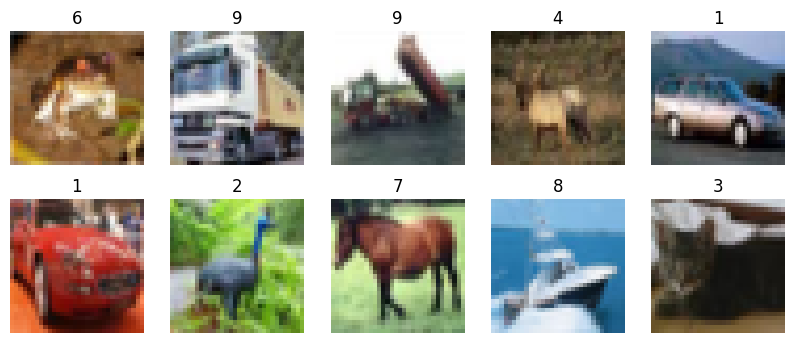

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    image, label = trainset[i]
    ax.imshow(image.permute(1,2,0))
    ax.set_title(label)
    ax.axis("off")

plt.show()

## 5. CNN Model Architecture

Defining a simple convolutional neural network for image classification.


In [10]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)


## 6. Training Configuration

Defining loss function and optimization strategy.


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


## 7. Experimental Framework

Running controlled batch-size experiments while logging GPU utilization and memory usage.


In [12]:
def run_experiment(initial_batch_size, mode="static"):

    print(f"\nStarting experiment | Mode: {mode} | Initial Batch Size: {initial_batch_size}")

    # 🔥 ADD THIS BLOCK
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SimpleCNN().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Comparative Analysis

Loading telemetry logs and comparing GPU utilization and memory usage across configurations.


In [13]:
# STATIC experiments
for bs in [16, 32, 64, 128]:
  run_experiment(bs, mode="static")

# ADAPTIVE experiment
run_experiment(32, mode="adaptive")


Starting experiment | Mode: static | Initial Batch Size: 16

Starting experiment | Mode: static | Initial Batch Size: 32

Starting experiment | Mode: static | Initial Batch Size: 64

Starting experiment | Mode: static | Initial Batch Size: 128

Starting experiment | Mode: adaptive | Initial Batch Size: 32


In [15]:


df_128 = pd.read_csv("gpu_log_128.csv")
df_256 = pd.read_csv("gpu_log_256.csv")

print("128 samples:", len(df_128))
print("256 samples:", len(df_256))

print("Average GPU Utilization:")
print("Batch 128:", df_128["GPU_Util"].mean())
print("Batch 256:", df_256["GPU_Util"].mean())

print("\nAverage GPU Memory Usage (MB):")
print("Batch 128:", df_128["Memory_MB"].mean())
print("Batch 256:", df_256["Memory_MB"].mean())



128 samples: 391
256 samples: 196
Average GPU Utilization:
Batch 128: 15.624040920716112
Batch 256: 14.423469387755102

Average GPU Memory Usage (MB):
Batch 128: 666.1875
Batch 256: 840.1875


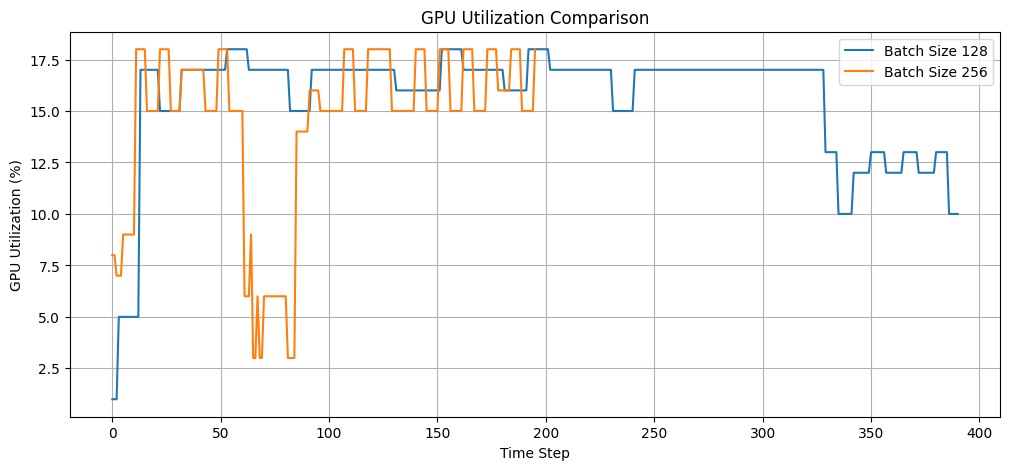

In [16]:
plt.figure(figsize=(12,5))

plt.plot(df_128["GPU_Util"], label="Batch Size 128")
plt.plot(df_256["GPU_Util"], label="Batch Size 256")

plt.title("GPU Utilization Comparison")
plt.xlabel("Time Step")
plt.ylabel("GPU Utilization (%)")
plt.legend()
plt.grid(True)

plt.show()


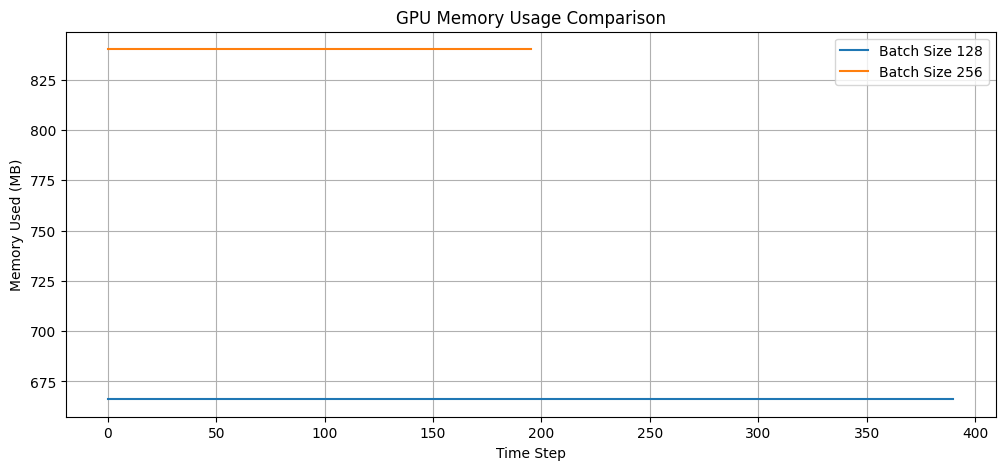

In [17]:
plt.figure(figsize=(12,5))

plt.plot(df_128["Memory_MB"], label="Batch Size 128")
plt.plot(df_256["Memory_MB"], label="Batch Size 256")

plt.title("GPU Memory Usage Comparison")
plt.xlabel("Time Step")
plt.ylabel("Memory Used (MB)")
plt.legend()
plt.grid(True)

plt.show()
